In [1]:
import os
import shutil
import random
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns

In [ ]:
BASE_PATH = r"E:\M.C.A\Project\AI-Real"
AI_SRC = os.path.join(BASE_PATH, "AiArtData", "AiArtData")
REAL_SRC = os.path.join(BASE_PATH, "RealArt", "RealArt")
SCRIPT_DIR = os.path.dirname(os.path.abspath('vision.ipynb'))
TARGET = os.path.join(SCRIPT_DIR, "data")
MODEL_SAVE_PATH = os.path.join(SCRIPT_DIR, "best_vit_model.pth")
SPLITS = {"train": 0.7, "val": 0.15, "test": 0.15}

batch_size = 64
num_classes = 2
num_channels = 3
img_size = 224
patch_size = 16

num_patches = (img_size // patch_size) ** 2  
attention_heads = 8
emd_dim = 256
transformer_blocks = 8
mlp_nodes = 512
learning_rate = 3e-4

def split_class(src_dir, class_name):
    images = [f for f in os.listdir(src_dir)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    random.shuffle(images)
    n = len(images)

    t1 = int(n * SPLITS["train"])
    t2 = int(n * (SPLITS["train"] + SPLITS["val"]))

    split_map = {
        "train": images[:t1],
        "val": images[t1:t2],
        "test": images[t2:]
    }

    for split, files in split_map.items():
        for f in files:
            shutil.copy(
                os.path.join(src_dir, f),
                os.path.join(TARGET, split, class_name, f)
            )

    print(f"{class_name.upper()} → {n} images")



In [60]:
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(
            in_channels=num_channels,
            out_channels=emd_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.patch_embed(x)          # [B, E, 14, 14]
        x = x.flatten(2)                 # [B, E, 196]
        x = x.transpose(1, 2)            # [B, 196, E]
        return x



In [61]:
class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(emd_dim)
        self.layer_norm2 = nn.LayerNorm(emd_dim)
        self.multi_head_attention = nn.MultiheadAttention(emd_dim, attention_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(emd_dim,mlp_nodes),
            nn.GELU(),
            nn.Linear(mlp_nodes,emd_dim)
        )

    def forward(self,x):
        residual1 = x
        attention_output = self.multi_head_attention(self.layer_norm1(x),self.layer_norm1(x),self.layer_norm1(x))[0]
        x = attention_output + residual1
        residual2 = x
        mlp_output = self.mlp(self.layer_norm2(x)) 
        x = mlp_output + residual2 
        return x



In [62]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding = PatchEmbedding()

        self.cls_token = nn.Parameter(torch.randn(1, 1, emd_dim) * 0.02)
        self.positional_embedding = nn.Parameter(
            torch.randn(1, num_patches + 1, emd_dim) * 0.02
        )

        self.transformer_blocks = nn.ModuleList(
            [TransformerEncoder() for _ in range(transformer_blocks)]
        )

        self.norm = nn.LayerNorm(emd_dim)

        self.classifier = nn.Sequential(
            nn.Linear(emd_dim, mlp_nodes),
            nn.ReLU(),
            nn.Linear(mlp_nodes, num_classes)
        )

    def forward(self, x):
        B = x.size(0)
                
        x = self.patch_embedding(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.positional_embedding

        for block in self.transformer_blocks:
            x = block(x)

        x = self.norm(x)

        cls_output = x[:, 0]  # CLS token
        return self.classifier(cls_output)


In [63]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()  

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)               
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()  

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def test_accuracy(model, dataloader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)          # [B, 2]
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy


In [64]:
random.seed(42)

for split in SPLITS:
    for cls in ["ai", "real"]:
        os.makedirs(os.path.join(TARGET, split, cls), exist_ok=True)
        

ai_copied = len(os.listdir(os.path.join(TARGET, "train", "ai"))) if os.path.exists(os.path.join(TARGET, "train", "ai")) else 0
if ai_copied == 0:
    split_class(AI_SRC, "ai")
    split_class(REAL_SRC, "real")
else:
    print("Dataset already split.")


for split in ["train", "val", "test"]:
    ai = len(os.listdir(os.path.join(TARGET, split, "ai")))
    real = len(os.listdir(os.path.join(TARGET, split, "real")))
    print(f"{split}: AI={ai}, Real={real}")


Dataset already split.
train: AI=375, Real=303
val: AI=80, Real=65
test: AI=81, Real=66


In [65]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = ImageFolder(os.path.join(TARGET, "train"), transform=train_transforms)
val_dataset   = ImageFolder(os.path.join(TARGET, "val"), transform=val_test_transforms)
test_dataset  = ImageFolder(os.path.join(TARGET, "test"), transform=val_test_transforms)

print("Class mapping:", train_dataset.class_to_idx)


Class mapping: {'ai': 0, 'real': 1}


In [66]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")


Batch shape: torch.Size([64, 3, 224, 224])


In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = VisionTransformer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)


ai_count = len(os.listdir(os.path.join(TARGET, "train", "ai")))
real_count = len(os.listdir(os.path.join(TARGET, "train", "real")))
total_count = ai_count + real_count
class_weights = torch.tensor([total_count / (2 * ai_count), total_count / (2 * real_count)],dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss()
print(class_weights)

Using device: cuda
tensor([0.9040, 1.1188], device='cuda:0')


In [78]:
EPOCHS = 10
best_val_acc = 0.0

print("Starting training...")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("Model saved")
       


Starting training...
Epoch [1/10] | Train Loss: 0.7172, Train Acc: 0.5797 | Val Loss: 0.6655, Val Acc: 0.6345
Model saved
Epoch [2/10] | Train Loss: 0.6469, Train Acc: 0.6375 | Val Loss: 0.6762, Val Acc: 0.6276
Epoch [3/10] | Train Loss: 0.6413, Train Acc: 0.6344 | Val Loss: 0.6322, Val Acc: 0.6759
Model saved
Epoch [4/10] | Train Loss: 0.6322, Train Acc: 0.6469 | Val Loss: 0.6301, Val Acc: 0.6414
Epoch [5/10] | Train Loss: 0.6257, Train Acc: 0.6453 | Val Loss: 0.6346, Val Acc: 0.6552
Epoch [6/10] | Train Loss: 0.6213, Train Acc: 0.6672 | Val Loss: 0.6468, Val Acc: 0.6414
Epoch [7/10] | Train Loss: 0.6184, Train Acc: 0.6687 | Val Loss: 0.6367, Val Acc: 0.6483
Epoch [8/10] | Train Loss: 0.6096, Train Acc: 0.6672 | Val Loss: 0.6376, Val Acc: 0.6345
Epoch [9/10] | Train Loss: 0.6062, Train Acc: 0.6687 | Val Loss: 0.6412, Val Acc: 0.6414
Epoch [10/10] | Train Loss: 0.6057, Train Acc: 0.6750 | Val Loss: 0.6480, Val Acc: 0.6276


In [ ]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
test_acc = test_accuracy(model, test_loader, device)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Test Accuracy: 60.54%


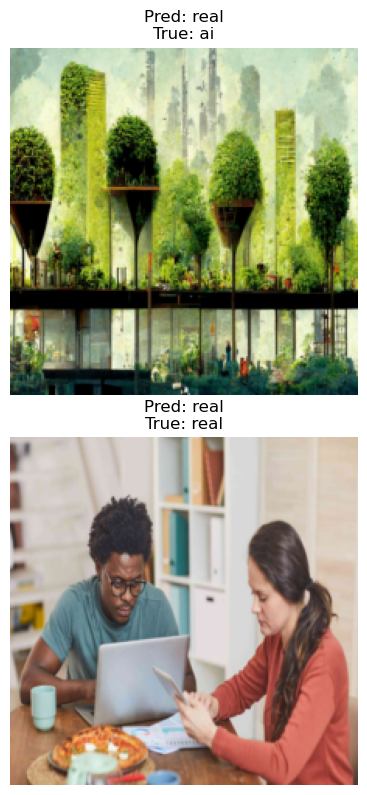

In [ ]:
model.eval()

ai_img, ai_lbl = None, None
real_img, real_lbl = None, None

for i in range(len(test_dataset)):
    img, lbl = test_dataset[i]
    if lbl == 0 and ai_img is None:
        ai_img, ai_lbl = img, lbl
    elif lbl == 1 and real_img is None:
        real_img, real_lbl = img, lbl
    if ai_img is not None and real_img is not None:
        break

images = torch.stack([ai_img, real_img]).to(device)
labels = torch.tensor([ai_lbl, real_lbl]).to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

class_names = train_dataset.classes

mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).to(device)

batch_size_viz = images.size(0)          
num_images = min(2, batch_size_viz)     

plt.figure(figsize=(16, 4 * num_images))
for i in range(num_images):
    img = images[i].permute(1, 2, 0)
    img = img * std + mean
    img = img.clamp(0, 1)

  
    # Image
    plt.subplot(num_images, 4, i * 4 + 1)
    plt.imshow(img.cpu())
    plt.title(
        f"Pred: {class_names[preds[i].item()]}\n"
        f"True: {class_names[labels[i].item()]}",
    )
    plt.axis("off")


plt.tight_layout()
plt.show() 





              precision    recall  f1-score   support

           0       0.68      0.58      0.63        81
           1       0.56      0.67      0.61        66

    accuracy                           0.62       147
   macro avg       0.62      0.62      0.62       147
weighted avg       0.63      0.62      0.62       147

Confusion Matrix:
[[47 34]
 [22 44]]


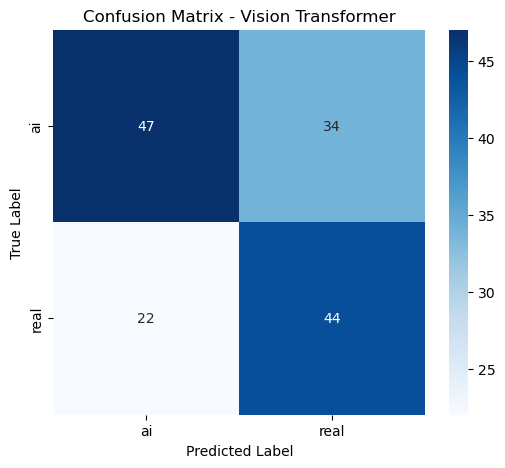

In [82]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
cls = classification_report(all_labels,all_preds)
print(cls)
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Vision Transformer")
plt.show()
